# UR3e Model

## 1. Initialization

In [2]:
%matplotlib ipympl
import roboticstoolbox as rtb
import numpy as np

In [17]:
# We will setup the robotic arm using the DH parameters given
# by Universal Robots. Source:
# https://www.universal-robots.com/articles/ur/application-installation/dh-parameters-for-calculations-of-kinematics-and-dynamics/
joint1 = rtb.RevoluteDH(d=0.15185, a=0, alpha=np.pi/2)
joint2 = rtb.RevoluteDH(d=0, a=-0.24355, alpha=0)
joint3 = rtb.RevoluteDH(d=0, a=-0.2132, alpha=0)
joint4 = rtb.RevoluteDH(d=0.13105, a=0, alpha=np.pi/2)
joint5 = rtb.RevoluteDH(d=0.08535, a=0, alpha=-np.pi/2)
joint6 = rtb.RevoluteDH(d=0.0921, a=0, alpha=0)

ur3e_model = rtb.DHRobot([joint1, joint2, joint3, joint4, joint5, joint6], name="UR3e Model")


## 2. Usage

### 2a. Forward Kinematics

(X, Y, Z):  [ 0.08535 -0.22315 -0.3049 ]
(R, P, Y):  [ 0.         -1.57079633  1.57079633]


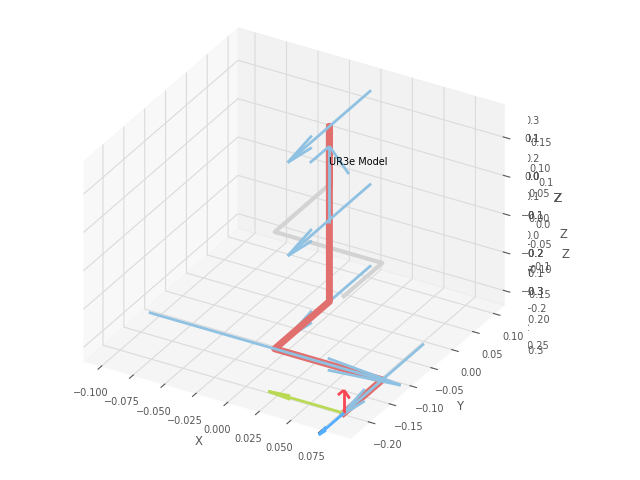

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'UR3e Model')

In [16]:
# Example: Give the target joint positions/rotations 
# in radians and use forward kinematics to find the 
# position of the head.
fk_joint_positions = [
    0,
    np.pi/2,
    0,
    0,
    0,
    0,
]

# The output is a SE(3) of the head/end position.
result = ur3e_model.fkine(fk_joint_positions)

# We can interpret the result as both the X,Y,Z coordinates:
xyz = result.t
print("(X, Y, Z): ", xyz)
# As well as the Roll,Pitch,Yaw (R,P,Y) values:
rpy = result.rpy()
print("(R, P, Y): ", rpy)

# We can also plot the positions in 3D space.
ur3e_model.plot(fk_joint_positions)

### 2b. Trajectories

[[0.         0.         0.         0.         0.         0.        ]
 [0.01811567 0.01811567 0.01811567 0.01811567 0.01811567 0.01811567]
 [0.1200263  0.1200263  0.1200263  0.1200263  0.1200263  0.1200263 ]
 [0.3296733  0.3296733  0.3296733  0.3296733  0.3296733  0.3296733 ]
 [0.62311526 0.62311526 0.62311526 0.62311526 0.62311526 0.62311526]
 [0.94768106 0.94768106 0.94768106 0.94768106 0.94768106 0.94768106]
 [1.24112302 1.24112302 1.24112302 1.24112302 1.24112302 1.24112302]
 [1.45077003 1.45077003 1.45077003 1.45077003 1.45077003 1.45077003]
 [1.55268066 1.55268066 1.55268066 1.55268066 1.55268066 1.55268066]
 [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633]]


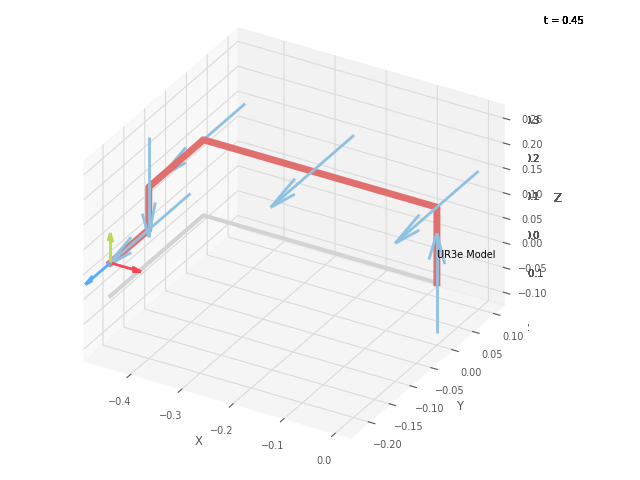

PyPlot3D backend, t = 0.49999999999999994, scene:
  robot: Text(0.0, 0.0, 'UR3e Model')

In [31]:
# Example: Give the initial and target joint 
# positions/rotations in radians, and step
# through the trajectory
start = [
    0,
    0,
    0,
    0,
    0,
    0,
]

end = [
    np.pi/2,
    np.pi/2,
    np.pi/2,
    np.pi/2,
    np.pi/2,
    np.pi/2,
]

trajectory = rtb.jtraj(start, end, 10)

# The steps of trajectory are given as an array-of-arrays.
steps = trajectory.q
print(steps)

# We can visualize the trajectory steps in 3D space:
ur3e_model.plot(steps)